# Chronos-2 Quickstart

This notebook is the repo's first operational baseline for Chronos-2. It assumes a local project environment is already set up from the repo root with `requirements.txt` and that the notebook is running on the repo's `.venv` kernel.

The goal is deliberately narrow:

- verify the notebook is attached to the expected Python environment,
- load the `amazon/chronos-2` model through the supported Chronos API,
- run a small forecast on a known public sample dataset,
- confirm the end-to-end prediction path with a visualization and simple accuracy metrics.

For the sample data, this notebook uses the **M4 hourly** dataset because it is also used in the official Chronos-2 quickstart notebook. The M4 data comes from the Makridakis 4 forecasting competition, a standard benchmark collection of real-world time series across multiple domains and frequencies. To keep the first test small, this notebook forecasts a single series (`H1`) for the next 24 hourly steps.

Notes:

- The first model download is large and can take a few minutes.
- GPU is preferred for speed, but the notebook falls back to CPU when no supported accelerator is available.
- On Apple silicon, PyTorch acceleration uses `mps`, not `cuda`.
- This is not yet the energy benchmarking workflow. It is only the initial operational smoke test.

## Environment And Kernel Setup

Recommended repo setup from the project root:

```bash
python -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name energy-forecast-model --display-name "Python (.venv) energy-forecast-model"
```

Then in VS Code:

1. Open this notebook.
2. Click **Select Kernel**.
3. Choose the interpreter or Jupyter kernel backed by `/Users/epeng/code/personal/energy-forecast-model/.venv/bin/python`.

Chronos-2 requires **Python 3.10+**. For this repo, Python 3.11 is the recommended baseline.

In [13]:
from __future__ import annotations

import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from chronos import BaseChronosPipeline, Chronos2Pipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

In [14]:
print(f"Python executable: {sys.executable}")
print(f"Python version:    {sys.version.split()[0]}")
print(f"Platform:          {platform.platform()}")
print(f"Torch version:     {torch.__version__}")

Python executable: /Users/epeng/code/personal/energy-forecast-model/.venv/bin/python
Python version:    3.11.15
Platform:          macOS-26.4.1-arm64-arm-64bit
Torch version:     2.11.0


In [15]:
def resolve_device_map() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


model_id = "amazon/chronos-2"
device_map = resolve_device_map()

print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
if getattr(torch.backends, "mps", None):
    print(f"torch.backends.mps.is_built(): {torch.backends.mps.is_built()}")
    print(f"torch.backends.mps.is_available(): {torch.backends.mps.is_available()}")
print(f"Loading {model_id} on device_map={device_map!r} ...")

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    model_id,
    device_map=device_map,
)

print(type(pipeline).__name__)
if platform.machine() == "arm64" and device_map == "cpu":
    print(
        "Apple silicon detected, but PyTorch MPS is not available in this runtime. "
        "The notebook will continue on CPU."
    )

torch.cuda.is_available(): False
torch.backends.mps.is_built(): True
torch.backends.mps.is_available(): True
Loading amazon/chronos-2 on device_map='mps' ...
Chronos2Pipeline


## Load a Small Official Sample

The official Chronos-2 quickstart uses the M4 hourly dataset. M4 is a widely used forecasting benchmark from the Makridakis 4 competition, and `m4_hourly` is its hourly subset. Here we keep only one series (`H1`) so the first forecast is fast enough to use as a smoke test.

In [16]:
train_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv"
test_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/test.csv"
example_item_id = "H1"
prediction_length = 24

context_df = pd.read_csv(train_url, parse_dates=["timestamp"])
test_df = pd.read_csv(test_url, parse_dates=["timestamp"])

series_context_df = (
    context_df.loc[context_df["item_id"] == example_item_id]
    .sort_values("timestamp")
    .reset_index(drop=True)
)
series_test_df = (
    test_df.loc[test_df["item_id"] == example_item_id]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

context_end = series_context_df["timestamp"].max()
series_future_df = series_test_df.loc[series_test_df["timestamp"] > context_end].copy()
if len(series_future_df) < prediction_length:
    series_future_df = series_test_df.tail(prediction_length).copy()
series_future_df = series_future_df.head(prediction_length).reset_index(drop=True)

print("Context rows:", len(series_context_df))
print("Evaluation rows:", len(series_future_df))
print("Context range:", series_context_df["timestamp"].min(), "->", series_context_df["timestamp"].max())
print("Future range: ", series_future_df["timestamp"].min(), "->", series_future_df["timestamp"].max())
display(series_context_df.head())
display(series_future_df.head())

Context rows: 700
Evaluation rows: 24
Context range: 1750-01-01 00:00:00 -> 1750-01-30 03:00:00
Future range:  1750-01-30 04:00:00 -> 1750-01-31 03:00:00


,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


,item_id,timestamp,target
0,H1,1750-01-30 04:00:00,619.0
1,H1,1750-01-30 05:00:00,565.0
2,H1,1750-01-30 06:00:00,532.0
3,H1,1750-01-30 07:00:00,495.0
4,H1,1750-01-30 08:00:00,481.0


In [17]:
pred_df = pipeline.predict_df(
    series_context_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
)

comparison_df = pred_df.merge(
    series_future_df[["timestamp", "target"]].rename(columns={"target": "actual"}),
    on="timestamp",
    how="left",
)

missing_actuals = int(comparison_df["actual"].isna().sum())
if missing_actuals:
    raise ValueError(f"Expected fully aligned actuals, but found {missing_actuals} missing rows.")

mae = float(np.mean(np.abs(comparison_df["predictions"] - comparison_df["actual"])))
rmse = float(np.sqrt(np.mean((comparison_df["predictions"] - comparison_df["actual"]) ** 2)))

display(comparison_df.head())
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

,item_id,timestamp,target_name,predictions,0.1,0.5,0.9,actual
0,H1,1750-01-30 04:00:00,target,624.867981,611.385132,624.867981,638.598755,619.0
1,H1,1750-01-30 05:00:00,target,563.703125,546.655090,563.703125,578.665710,565.0
2,H1,1750-01-30 06:00:00,target,521.589844,505.747467,521.589844,537.950806,532.0
3,H1,1750-01-30 07:00:00,target,489.910706,473.671814,489.910706,508.854126,495.0
4,H1,1750-01-30 08:00:00,target,471.144470,452.199402,471.144470,491.050293,481.0


MAE:  13.082
RMSE: 18.979


## What The Metrics Mean

- **MAE (Mean Absolute Error)** is the average absolute miss between the forecast and the true value. It stays in the same units as the target series, so `MAE = 13` means the forecast is off by about 13 units on average.
- **RMSE (Root Mean Squared Error)** is the square root of average squared error. It is also in the same units as the target series, but it penalizes larger misses more heavily than MAE.
- **sMAPE (Symmetric Mean Absolute Percentage Error)** expresses error as a percentage based on the size of both the prediction and the actual value. It is scale-free, which makes it easier to compare performance across different series.
- **MASE (Mean Absolute Scaled Error)** scales the model's MAE by the MAE of a naive seasonal baseline on the history. Values below `1.0` mean the model beats that baseline; values above `1.0` mean it does worse.

This notebook uses **sMAPE** instead of plain **MAPE** because `MAPE = |y - y_hat| / |y|` becomes unstable or undefined when the actual value is near zero. `sMAPE` uses both the prediction and the actual value in the denominator, which is usually more robust for forecasting benchmarks.

For this hourly M4 example, a natural naive baseline is a **seasonal naive forecast with period 24**, which predicts each hour using the value from the same hour one day earlier.

In [18]:
seasonal_period = 24

actual = comparison_df["actual"].to_numpy(dtype=float)
forecast = comparison_df["predictions"].to_numpy(dtype=float)
naive_forecast = series_context_df["target"].tail(seasonal_period).to_numpy(dtype=float)

if len(naive_forecast) != len(actual):
    raise ValueError("Seasonal naive baseline length does not match the forecast horizon.")

naive_mae = float(np.mean(np.abs(actual - naive_forecast)))
naive_rmse = float(np.sqrt(np.mean((actual - naive_forecast) ** 2)))
smape = float(
    100
    * np.mean(2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast)))
)
naive_smape = float(
    100
    * np.mean(
        2 * np.abs(naive_forecast - actual) / (np.abs(actual) + np.abs(naive_forecast))
    )
)

history_values = series_context_df["target"].to_numpy(dtype=float)
seasonal_diffs = np.abs(history_values[seasonal_period:] - history_values[:-seasonal_period])
mase_scale = float(np.mean(seasonal_diffs))
mase = mae / mase_scale
naive_mase = naive_mae / mase_scale

baseline_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "sMAPE", "MASE"],
        "chronos_2": [mae, rmse, smape, mase],
        "seasonal_naive_24h": [naive_mae, naive_rmse, naive_smape, naive_mase],
    }
)

display(baseline_df)
print("Interpretation:")
print("- Lower is better for all four metrics.")
print("- MASE < 1.0 means Chronos-2 beats the seasonal naive baseline on this window.")

,metric,chronos_2,seasonal_naive_24h
0,MAE,13.082306,33.500000
1,RMSE,18.979121,38.955102
2,sMAPE,1.841935,4.952257
3,MASE,0.308754,0.790629


Interpretation:
- Lower is better for all four metrics.
- MASE < 1.0 means Chronos-2 beats the seasonal naive baseline on this window.


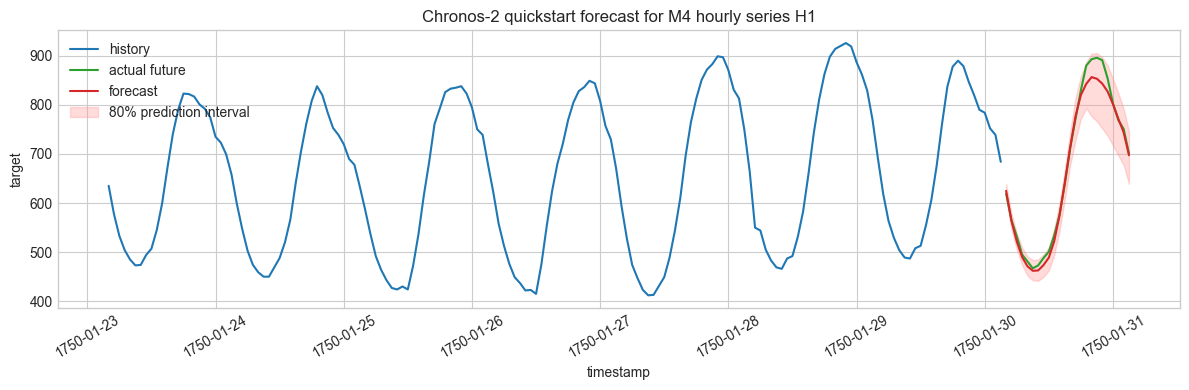

In [19]:
history_window = 7 * 24
history_df = series_context_df.tail(history_window)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history_df["timestamp"], history_df["target"], label="history", color="#1f77b4")
ax.plot(comparison_df["timestamp"], comparison_df["actual"], label="actual future", color="#2ca02c")
ax.plot(comparison_df["timestamp"], comparison_df["predictions"], label="forecast", color="#d62728")
ax.fill_between(
    comparison_df["timestamp"],
    comparison_df["0.1"],
    comparison_df["0.9"],
    color="#ff9896",
    alpha=0.35,
    label="80% prediction interval",
)
ax.set_title(f"Chronos-2 quickstart forecast for M4 hourly series {example_item_id}")
ax.set_xlabel("timestamp")
ax.set_ylabel("target")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## What To Scale Next

Once this notebook runs successfully, the next repo steps for energy benchmarking are straightforward:

1. Swap the M4 example for an energy dataset that matches the benchmark target.
2. Expand from a single series to many series through the long-format `predict_df` interface.
3. Add covariates and future-known features for Chronos-2, which is where it differs most from older Chronos variants.
4. Standardize metrics, backtest splits, and runtime logging for repeatable benchmarks.